In [5]:
import glob
import sunpy.map
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

files_regular = sorted(
    glob.glob(
        "../data/20260820T154500/solo_L2_eui-hrieuv174-image_*.fits"
    )
)

print("Number of files:", len(files_regular))
print("First 5:")
for f in files_regular[:5]:
    print(f)

print("\nLast 5:")
for f in files_regular[-5:]:
    print(f)


Number of files: 45
First 5:
../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T154556280_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T154656280_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T154756280_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T154856280_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T154956280_V00.fits

Last 5:
../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T162556343_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T162656385_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T162756285_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T162856285_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T162956285_V00.fits


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sunpy.map
import astropy.units as u
from astropy.coordinates import SkyCoord
from scipy.signal import find_peaks

brightness_regular = []
times_regular = []

zoom_width = 150 * u.arcsec
zoom_height = 150 * u.arcsec

for file in files_regular:

    map_i = sunpy.map.Map(file)

    bottom_left_i = SkyCoord(
        -1370 * u.arcsec - zoom_width / 2,
        375 * u.arcsec - zoom_height / 2,
        frame=map_i.coordinate_frame
    )

    top_right_i = SkyCoord(
        -1370 * u.arcsec + zoom_width / 2,
        375 * u.arcsec + zoom_height / 2,
        frame=map_i.coordinate_frame
    )

    roi_i = map_i.submap(
        bottom_left_i,
        top_right=top_right_i
    )

    #rum all pixels in the ROI
    total_brightness = np.sum(roi_i.data)

    brightness_regular.append(total_brightness)
    times_regular.append(map_i.date.datetime)

print("Number of measurements:", len(brightness_regular))

Number of measurements: 45


In [8]:
lightcurve_regular = pd.DataFrame({
    "time": times_regular,
    "brightness": brightness_regular
})

lightcurve_regular = lightcurve_regular.sort_values("time")

print(lightcurve_regular.head())

                     time   brightness
0 2026-08-20 15:45:56.280  348553312.0
1 2026-08-20 15:46:56.280  347390016.0
2 2026-08-20 15:47:56.280  345296640.0
3 2026-08-20 15:48:56.280  339357632.0
4 2026-08-20 15:49:56.280  346845376.0


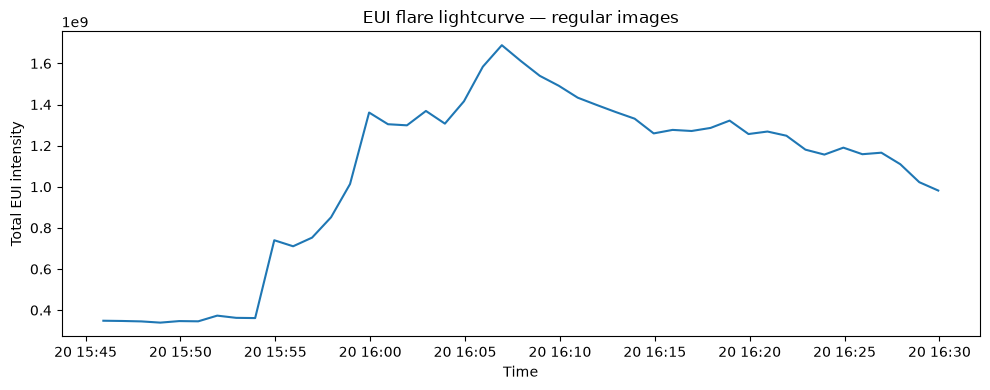

In [9]:
plt.figure(figsize=(10, 4))

plt.plot(
    lightcurve_regular["time"],
    lightcurve_regular["brightness"]
)

plt.xlabel("Time")
plt.ylabel("Total EUI intensity")
plt.title("EUI flare lightcurve — regular images")

plt.tight_layout()

plt.savefig(
    "../figures/eui_lightcurve_regular.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
files_short = sorted(
    glob.glob(
        "../data/20260820T154500/solo_L2_eui-hrieuv174-image-short_*.fits"
    )
)

print("Number of short files:", len(files_short))



Number of short files: 1260
First 5:
../data/20260820T154500\solo_L2_eui-hrieuv174-image-short_20260820T154500280_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image-short_20260820T154502280_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image-short_20260820T154504280_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image-short_20260820T154506286_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image-short_20260820T154508692_V00.fits

Last 5:
../data/20260820T154500\solo_L2_eui-hrieuv174-image-short_20260820T162946285_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image-short_20260820T162948285_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image-short_20260820T162950285_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image-short_20260820T162952311_V00.fits
../data/20260820T154500\solo_L2_eui-hrieuv174-image-short_20260820T162954285_V00.fits


In [11]:
brightness_short = []
times_short = []

for i, file in enumerate(files_short):

    map_i = sunpy.map.Map(file)

    bottom_left_i = SkyCoord(
        -1370 * u.arcsec - zoom_width / 2,
        375 * u.arcsec - zoom_height / 2,
        frame=map_i.coordinate_frame
    )

    top_right_i = SkyCoord(
        -1370 * u.arcsec + zoom_width / 2,
        375 * u.arcsec + zoom_height / 2,
        frame=map_i.coordinate_frame
    )

    roi_i = map_i.submap(
        bottom_left_i,
        top_right=top_right_i
    )

    total_brightness = np.nansum(roi_i.data)

    brightness_short.append(total_brightness)
    times_short.append(map_i.date.datetime)

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(files_short)}")

Processed 100/1260
Processed 200/1260
Processed 300/1260
Processed 400/1260
Processed 500/1260
Processed 600/1260
Processed 700/1260
Processed 800/1260
Processed 900/1260
Processed 1000/1260
Processed 1100/1260
Processed 1200/1260


In [12]:
lightcurve_short = pd.DataFrame({
    "time": times_short,
    "brightness": brightness_short
})

lightcurve_short = lightcurve_short.sort_values("time")

print(lightcurve_short.head())
print(lightcurve_short.tail())

                     time   brightness
0 2026-08-20 15:45:00.280  227256224.0
1 2026-08-20 15:45:02.280  228100256.0
2 2026-08-20 15:45:04.280  228969664.0
3 2026-08-20 15:45:06.286  228092288.0
4 2026-08-20 15:45:08.692  228668336.0
                        time   brightness
1255 2026-08-20 16:29:46.285  746174464.0
1256 2026-08-20 16:29:48.285  745341824.0
1257 2026-08-20 16:29:50.285  742999872.0
1258 2026-08-20 16:29:52.311  741129344.0
1259 2026-08-20 16:29:54.285  738391936.0


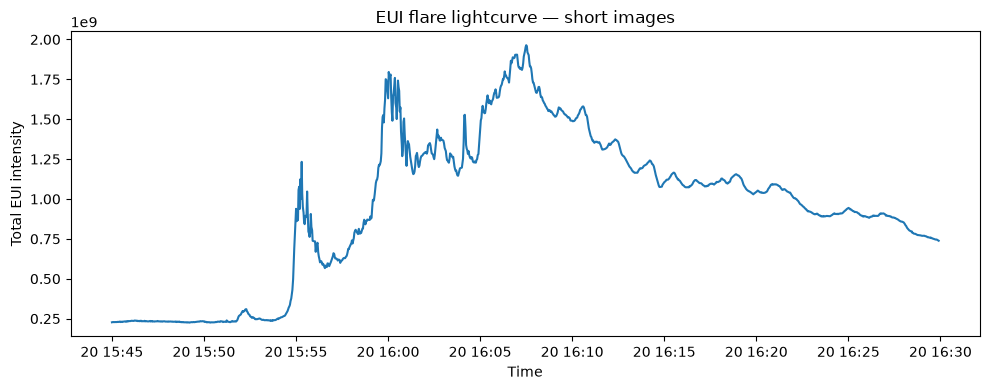

In [13]:
plt.figure(figsize=(10, 4))

plt.plot(
    lightcurve_short["time"],
    lightcurve_short["brightness"]
)

plt.xlabel("Time")
plt.ylabel("Total EUI intensity")
plt.title("EUI flare lightcurve — short images")

plt.tight_layout()

plt.savefig(
    "../figures/eui_lightcurve_short.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Number of peaks: 23
2026-08-20 15:55:00.281000
2026-08-20 15:55:10.280000
2026-08-20 15:55:14.281000
2026-08-20 15:55:18.580000
2026-08-20 15:55:36.281000
2026-08-20 15:55:48.281000
2026-08-20 15:56:10.281000
2026-08-20 15:57:02.281000
2026-08-20 15:58:14.282000
2026-08-20 15:58:24.737000
2026-08-20 15:58:42.282000
2026-08-20 15:59:44.306000
2026-08-20 15:59:52.317000
2026-08-20 16:00:02.282000
2026-08-20 16:00:08.282000
2026-08-20 16:00:22.321000
2026-08-20 16:00:32.281000
2026-08-20 16:00:40.282000
2026-08-20 16:00:52.282000
2026-08-20 16:01:04.453000
2026-08-20 16:01:34.282000
2026-08-20 16:02:16.282000
2026-08-20 16:02:40.282000


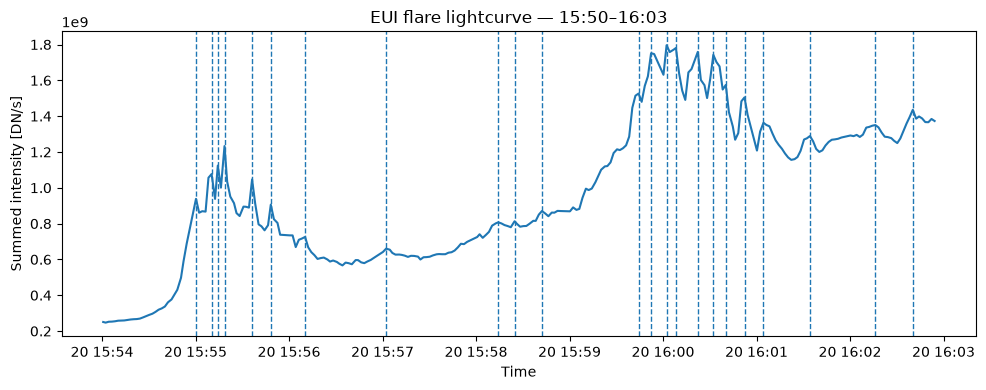

In [ ]:


start_time = pd.Timestamp("2026-08-20 15:54:00")
end_time = pd.Timestamp("2026-08-20 16:03:00")

zoomed_lightcurve = lightcurve_short[
    (lightcurve_short["time"] >= start_time) &
    (lightcurve_short["time"] <= end_time)
]

from scipy.signal import find_peaks

y = zoomed_lightcurve["brightness"].to_numpy()

peaks, properties = find_peaks(
    y,
    prominence=np.std(y) * 0.05,
    distance=2
)

peak_times = zoomed_lightcurve.iloc[peaks]["time"]

print("Number of peaks:", len(peaks))

for t in peak_times:
    print(t)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    zoomed_lightcurve["time"],
    y
)

for t in peak_times:
    ax.axvline(
        t,
        linestyle="--",
        linewidth=1
    )

ax.set_xlabel("Time")
ax.set_ylabel("Summed intensity [DN/s]")
ax.set_title("EUI flare lightcurve — 15:50–16:03")

plt.tight_layout()
plt.show()